# **Imports & Load Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Project Datasets/Mall Customers Dataset.csv')
df = df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'SpendingScore'})
print('Shape:', df.shape)
df.head()

Mounted at /content/drive
Shape: (200, 5)


,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Dataset Overview**

In [ ]:
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)

Shape: (200, 5)

Dtypes:
CustomerID        int64
Gender           object
Age               int64
Income            int64
SpendingScore     int64
dtype: object


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Income,200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
SpendingScore,200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


# **Missing / Invalid Values**

In [ ]:
missing = df.isnull().sum()
print('Missing:'); print(missing[missing > 0] if missing.sum() else 'None')
print('Duplicates:', df.duplicated().sum())

Missing:
None
Duplicates: 0


# **Univariate Distributions**

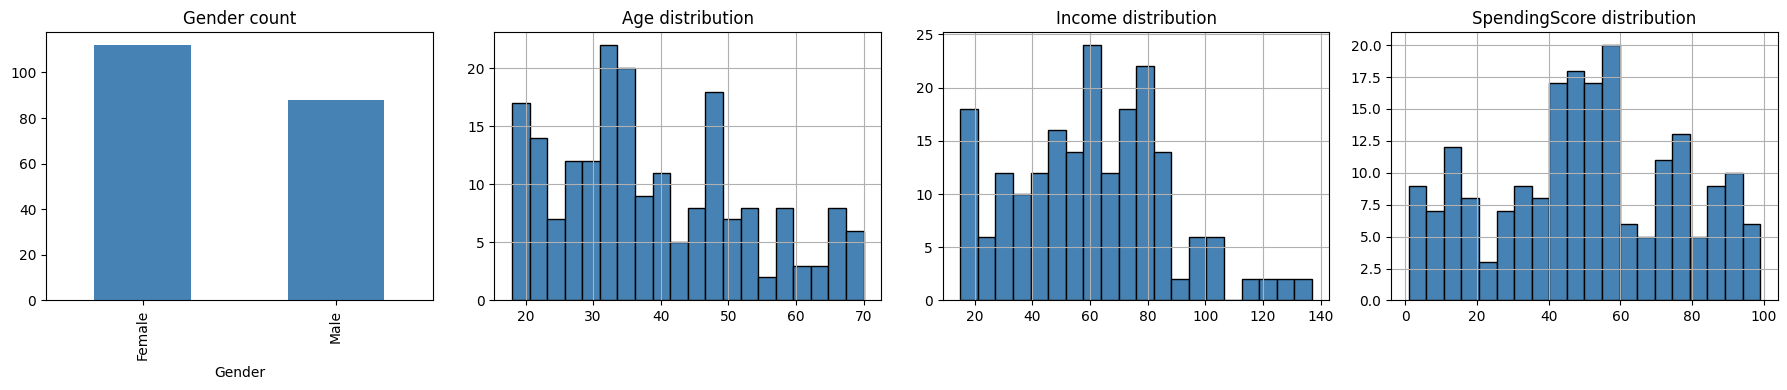

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
df['Gender'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Gender count')
for ax, col in zip(axes[1:], ['Age', 'Income', 'SpendingScore']):
    df[col].hist(ax=ax, bins=20, color='steelblue', edgecolor='black')
    ax.set_title(f'{col} distribution')
plt.tight_layout(); plt.show()

# **Bivariate — Income vs Spending Score (the headline plot)**

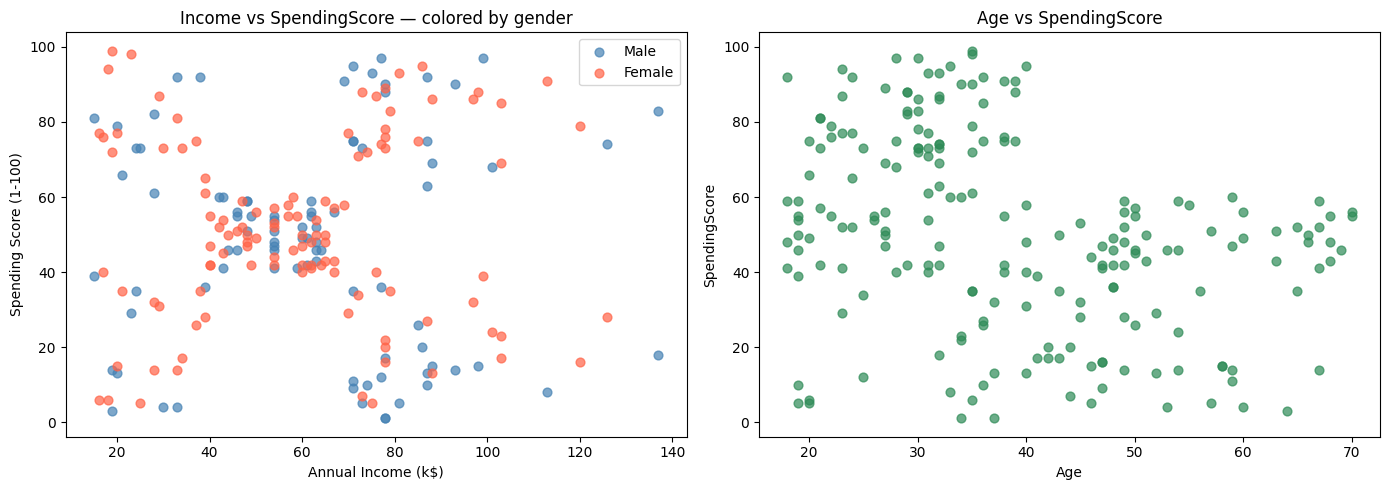

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for g, c in [('Male', 'steelblue'), ('Female', 'tomato')]:
    sub = df[df['Gender'] == g]
    axes[0].scatter(sub['Income'], sub['SpendingScore'], label=g, color=c, alpha=0.7, s=40)
axes[0].set_xlabel('Annual Income (k$)'); axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Income vs SpendingScore — colored by gender'); axes[0].legend()
axes[1].scatter(df['Age'], df['SpendingScore'], color='seagreen', alpha=0.7, s=40)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('SpendingScore')
axes[1].set_title('Age vs SpendingScore')
plt.tight_layout(); plt.show()

# **Pair Plot**

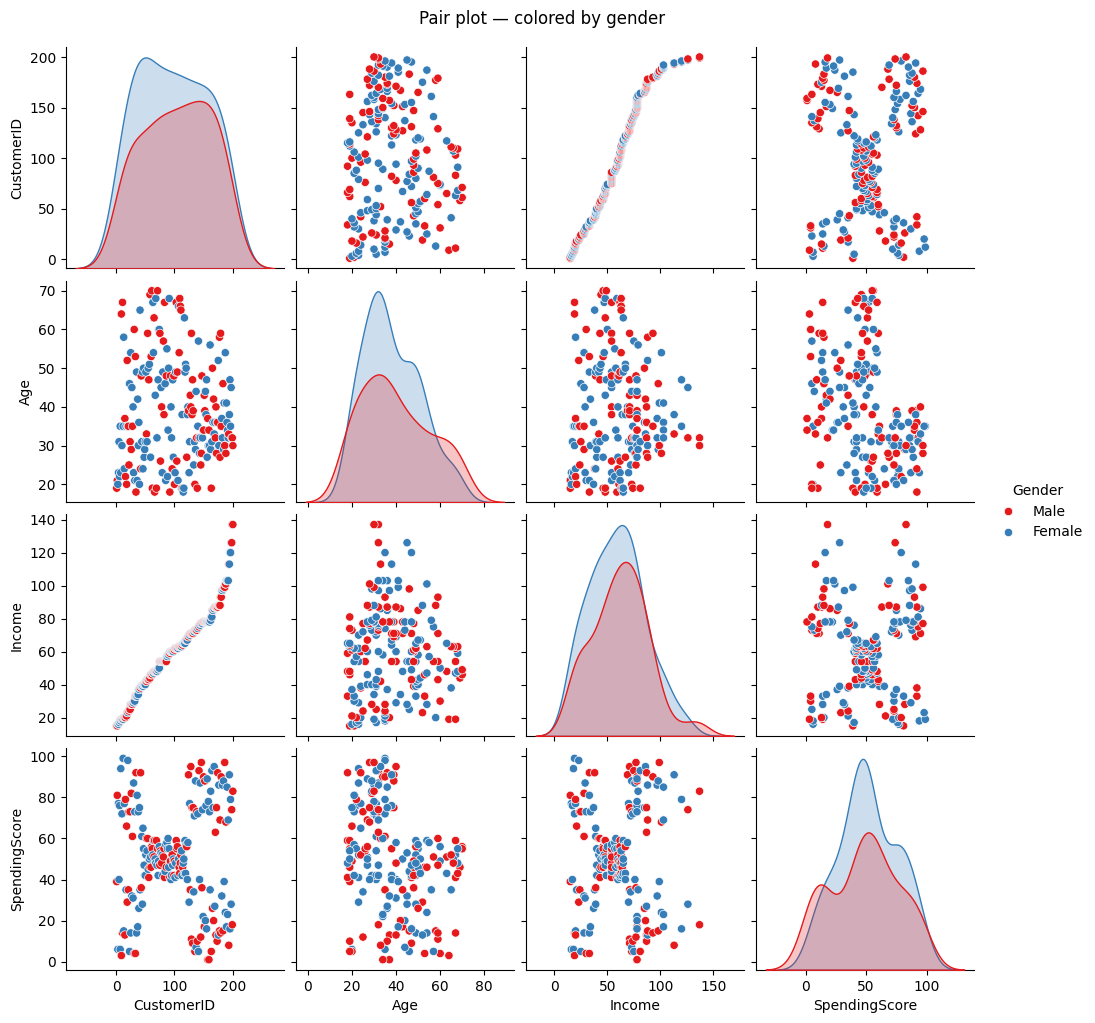

In [ ]:
sns.pairplot(df, hue='Gender', diag_kind='kde', height=2.5, palette='Set1')
plt.suptitle('Pair plot — colored by gender', y=1.02); plt.show()

# **Correlation**

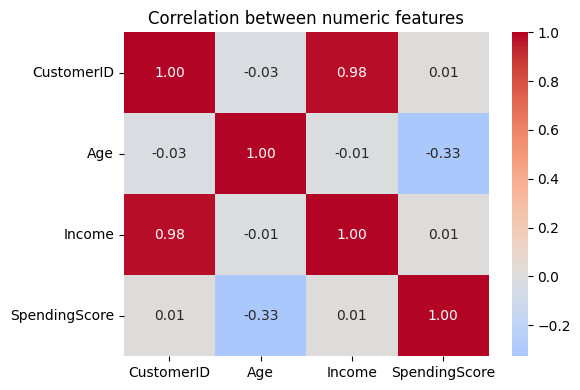

In [ ]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(6, 4))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation between numeric features')
plt.tight_layout(); plt.show()

# **Summary**

In [ ]:
print('Total customers:', len(df))
print('Gender split:', df['Gender'].value_counts().to_dict())
print('Mean Age:', round(df['Age'].mean(), 1))
print('Mean Income (k$):', round(df['Income'].mean(), 1))
print('Mean SpendingScore:', round(df['SpendingScore'].mean(), 1))

Total customers: 200
Gender split: {'Female': 112, 'Male': 88}
Mean Age: 38.8
Mean Income (k$): 60.6
Mean SpendingScore: 50.2
